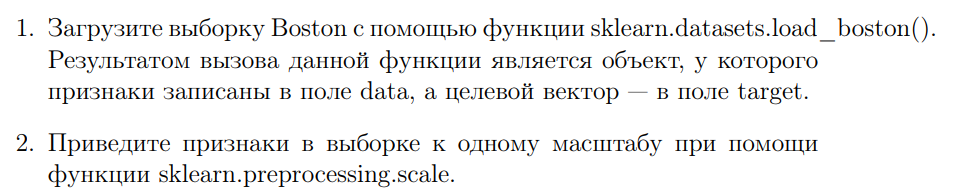

In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загружаем датасет Boston
boston = fetch_openml(name='boston', version=1, parser='auto', as_frame=False)
X = boston.data
y = boston.target

# Масштабируем признаки
X_scaled = scale(X)

# Проверяем результат масштабирования
print('Проверка масштабирования:')
print(f'  Среднее значение: {X_scaled.mean():.10f}')
print(f'  Стандартное отклонение: {X_scaled.std():.10f}')
print(f'  Min: {X_scaled.min():.4f}')
print(f'  Max: {X_scaled.max():.4f}')

Проверка масштабирования:
  Среднее значение: -0.0000000000
  Стандартное отклонение: 1.0000000000
  Min: -3.9072
  Max: 9.9339


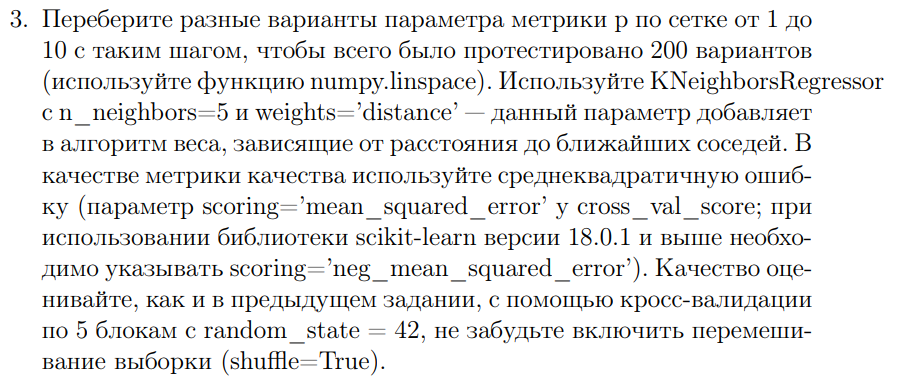

In [10]:
# Создаём генератор разбиений KFold (5-fold cross-validation)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Создаём сетку значений p от 1 до 10 (200 вариантов)
p_values = np.linspace(1, 10, 200)

print(f'Количество тестируемых значений p: {len(p_values)}')
print(f'Диапазон p: [{p_values[0]:.4f}, {p_values[-1]:.4f}]')
print(f'Шаг между значениями: {p_values[1] - p_values[0]:.4f}\n')

# Ищем оптимальное p
mse_scores = []

print('Вычисление MSE для всех значений p...')
for i, p in enumerate(p_values):
    # Проверяем версию scikit-learn
    regressor = KNeighborsRegressor(n_neighbors=5, weights='distance', p=p)
    
    # Попробуем использовать 'neg_mean_squared_error' (для новых версий)
    try:
        scores = cross_val_score(regressor, X_scaled, y, cv=kfold, scoring='neg_mean_squared_error')
    except:
        # Если не работает, используем 'mean_squared_error' (для старых версий)
        scores = cross_val_score(regressor, X_scaled, y, cv=kfold, scoring='mean_squared_error')
    
    # Берём среднее значение
    mean_score = scores.mean()
    mse_scores.append(mean_score)
    

print('Готово!')

Количество тестируемых значений p: 200
Диапазон p: [1.0000, 10.0000]
Шаг между значениями: 0.0452

Вычисление MSE для всех значений p...
Готово!


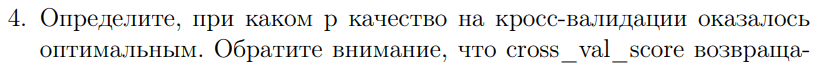
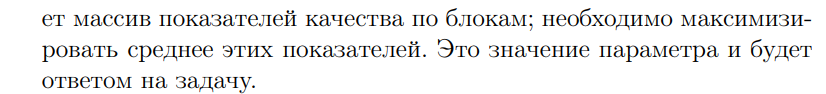

In [8]:
optimal_idx = np.argmax(mse_scores)  # Индекс максимального (ближайшего к нулю) значения
optimal_p = p_values[optimal_idx]
optimal_mse = mse_scores[optimal_idx]

print(f'\nОптимальное значение p: {optimal_p:.1f}')
print(f'Среднеквадратичная ошибка (MSE): {optimal_mse:.4f}')
print(f'\nДополнительная информация:')
print(f'  Min MSE: {min(mse_scores):.4f} (при p={p_values[np.argmin(mse_scores)]:.4f})')
print(f'  Max MSE: {max(mse_scores):.4f} (при p={p_values[np.argmax(mse_scores)]:.4f})')
print(f'  Mean MSE: {np.mean(mse_scores):.4f}')
print(f'  Median MSE: {np.median(mse_scores):.4f}')


Оптимальное значение p: 1.0
Среднеквадратичная ошибка (MSE): -16.0306

Дополнительная информация:
  Min MSE: -21.1125 (при p=9.5025)
  Max MSE: -16.0306 (при p=1.0000)
  Mean MSE: -19.5276
  Median MSE: -19.8165
